In [42]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans 

In [2]:
df = pd.read_csv("D://Machine Learning//sampledata//Projects//Online Retail.csv")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/2010 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/2010 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/09/2011 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/09/2011 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/09/2011 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/09/2011 12:50:00,4.15,12680.0,France


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# Data Cleaning

In [4]:
df.drop(columns=['StockCode','Description'],inplace=True)

In [5]:
df

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,6,12/01/2010 08:26:00,2.55,17850.0,United Kingdom
1,536365,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
2,536365,8,12/01/2010 08:26:00,2.75,17850.0,United Kingdom
3,536365,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
4,536365,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...
541904,581587,12,12/09/2011 12:50:00,0.85,12680.0,France
541905,581587,6,12/09/2011 12:50:00,2.10,12680.0,France
541906,581587,4,12/09/2011 12:50:00,4.15,12680.0,France
541907,581587,4,12/09/2011 12:50:00,4.15,12680.0,France


In [6]:
df_cleaned = df.dropna(subset=['CustomerID'])

In [7]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   Quantity     406829 non-null  int64  
 2   InvoiceDate  406829 non-null  object 
 3   UnitPrice    406829 non-null  float64
 4   CustomerID   406829 non-null  float64
 5   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 21.7+ MB


# Feature Engineering

In [8]:
df[df['InvoiceNo'].str.contains('C',na=False)]

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,-1,12/01/2010 09:41:00,27.50,14527.0,United Kingdom
154,C536383,-1,12/01/2010 09:49:00,4.65,15311.0,United Kingdom
235,C536391,-12,12/01/2010 10:24:00,1.65,17548.0,United Kingdom
236,C536391,-24,12/01/2010 10:24:00,0.29,17548.0,United Kingdom
237,C536391,-24,12/01/2010 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...
540449,C581490,-11,12/09/2011 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,-1,12/09/2011 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,-5,12/09/2011 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,-1,12/09/2011 11:58:00,1.25,17315.0,United Kingdom


In [9]:
df[~df['InvoiceNo'].str.contains('C',na=False)]

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,6,12/01/2010 08:26:00,2.55,17850.0,United Kingdom
1,536365,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
2,536365,8,12/01/2010 08:26:00,2.75,17850.0,United Kingdom
3,536365,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
4,536365,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...
541904,581587,12,12/09/2011 12:50:00,0.85,12680.0,France
541905,581587,6,12/09/2011 12:50:00,2.10,12680.0,France
541906,581587,4,12/09/2011 12:50:00,4.15,12680.0,France
541907,581587,4,12/09/2011 12:50:00,4.15,12680.0,France


In [10]:
df_cleaned = df[~df['InvoiceNo'].str.contains('C',na=False)]

In [ ]:
df_cleaned['TotalSum'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']

In [ ]:
df_cleaned['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [13]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 532621 entries, 0 to 541908
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    532621 non-null  object        
 1   Quantity     532621 non-null  int64         
 2   InvoiceDate  532621 non-null  datetime64[ns]
 3   UnitPrice    532621 non-null  float64       
 4   CustomerID   397924 non-null  float64       
 5   Country      532621 non-null  object        
 6   TotalSum     532621 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(2)
memory usage: 32.5+ MB


In [14]:
df['InvoiceDate'].max()

'12/23/2010 17:41:00'

In [15]:
pd.to_datetime(df['InvoiceDate'].max())

Timestamp('2010-12-23 17:41:00')

In [16]:
pd.Timedelta(days=1)

Timedelta('1 days 00:00:00')

In [17]:
pd.to_datetime(df['InvoiceDate'].max()) + pd.Timedelta(days=1)

Timestamp('2010-12-24 17:41:00')

In [18]:
snapeshot = pd.to_datetime(df['InvoiceDate']).max() + pd.Timedelta(days=1)

In [19]:
rmf = df_cleaned.groupby('CustomerID').agg(
    {
        'InvoiceDate': lambda x: (snapeshot - x.max()).days,
        'InvoiceNo':'nunique',
        'TotalSum': 'sum'
    }
)

rmf.columns = ['Recency', 'Frequency', 'Monetary']

In [20]:
rmf 

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
...,...,...,...
18280.0,278,1,180.60
18281.0,181,1,80.82
18282.0,8,2,178.05


# EDA

<Axes: xlabel='Frequency', ylabel='Count'>

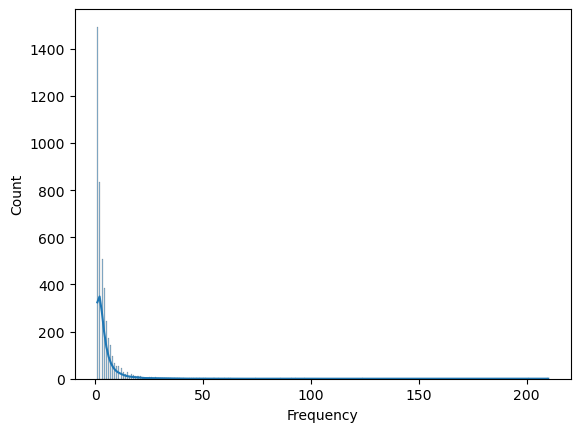

In [31]:
sns.histplot(x=rmf['Frequency'], kde=True)

<Axes: xlabel='Monetary', ylabel='Count'>

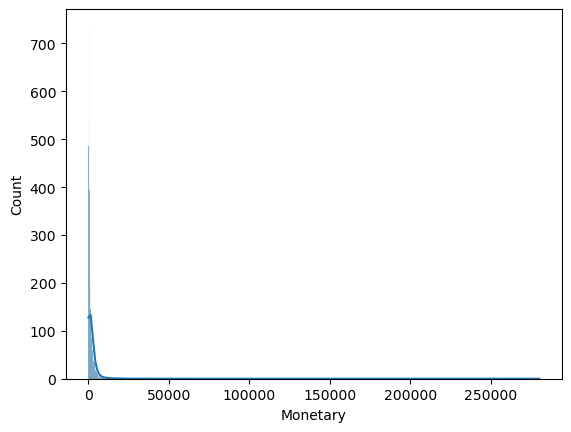

In [32]:
sns.histplot(x=rmf['Monetary'],kde=True)

<Axes: xlabel='Recency', ylabel='Count'>

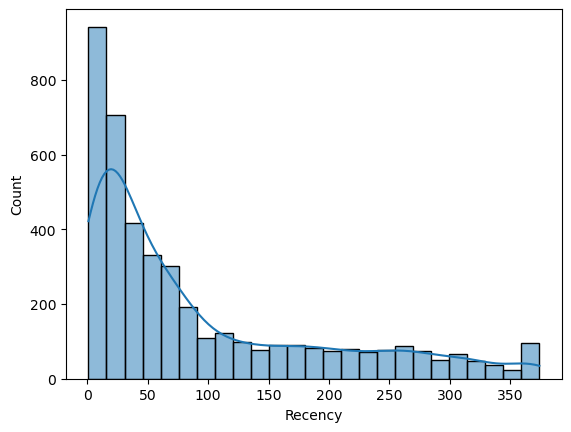

In [33]:
sns.histplot(x=rmf['Recency'], kde=True)

# Preprocessing

In [34]:
rmf_log = np.log1p(rmf)

In [40]:
scaler = StandardScaler()
rmf_log_scaled = scaler.fit_transform(rmf_log)

In [41]:
rmf_df = pd.DataFrame(rmf_log_scaled, index=rmf.index, columns=rmf.columns)
rmf_df

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,1.462236,-0.955013,3.696168
12347.0,-2.038611,1.074523,1.408758
12348.0,0.373310,0.386437,0.715517
12349.0,-0.622914,-0.955013,0.697821
12350.0,1.424800,-0.955013,-0.615877
...,...,...,...
18280.0,1.343773,-0.955013,-1.102307
18281.0,1.024977,-0.955013,-1.734438
18282.0,-1.218789,-0.361412,-1.113519


# Model Training

In [51]:
wcss = []

for i in range(1,21):
    kmeans_model = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans_model.fit(rmf_df)
    wcss.append(kmeans_model.inertia_)

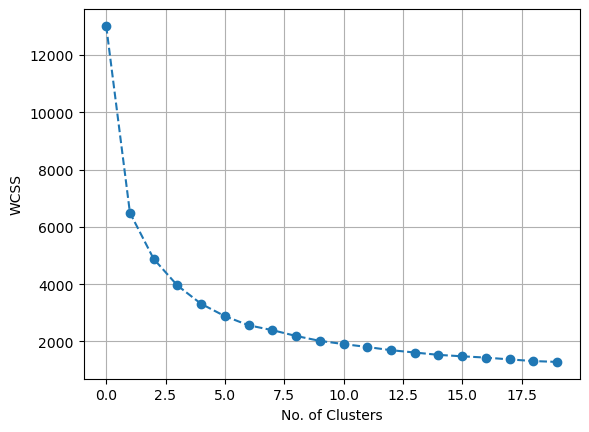

In [52]:
plt.plot(wcss, marker='o', linestyle='--')
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [67]:
final_model = KMeans(n_clusters=4, init='k-means++', random_state=42)

In [68]:
cluster_labels = final_model.fit_predict(rmf_df) 

In [69]:
rmf_df['cluster_labels'] = cluster_labels

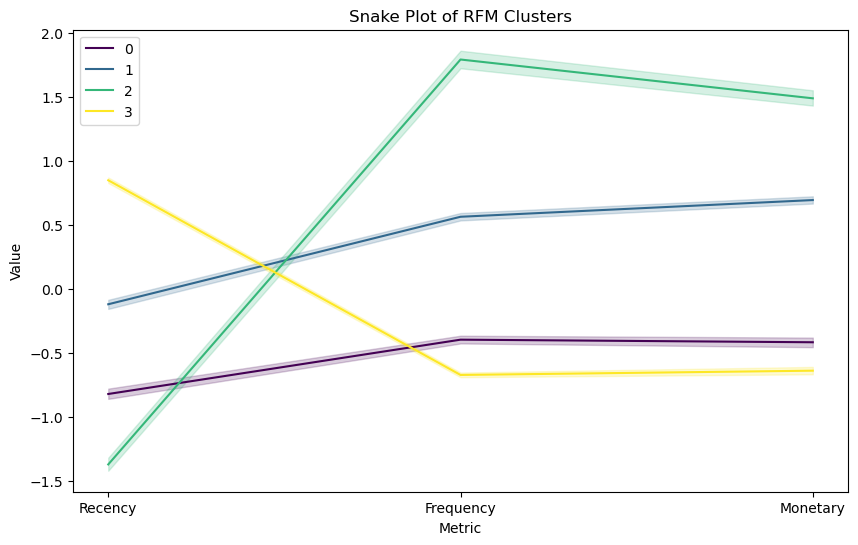

In [75]:
rmf_melted = pd.melt(rmf_df.reset_index(), 
                    id_vars=['CustomerID', 'cluster_labels'],
                    value_vars=['Recency', 'Frequency', 'Monetary'], 
                    var_name='Metric', 
                    value_name='Value')

plt.figure(figsize=(10, 6))
sns.lineplot(data=rmf_melted, x='Metric', y='Value', hue='cluster_labels', palette='viridis')
plt.title('Snake Plot of RFM Clusters')
plt.legend()
plt.show()

In [83]:
rmf_df['cluster_labels'].value_counts()

cluster_labels
3    1907
1    1006
0     839
2     587
Name: count, dtype: int64

In [84]:
print(rmf_df.groupby('cluster_labels')[['Recency', 'Frequency', 'Monetary']].mean())

                 Recency  Frequency  Monetary
cluster_labels                               
0              -0.821476  -0.397338 -0.417586
1              -0.120882   0.562265  0.692690
2              -1.371385   1.790071  1.487091
3               0.847314  -0.672807 -0.639441


In [88]:
cluster_names = {
    0:'At Risk',
    1:'Loyalist',
    2:'High Spender',
    3:'Lost'
}
rmf_df['Segments'] = rmf_df['cluster_labels'].map(cluster_names)

In [89]:
rmf_df

,Recency,Frequency,Monetary,cluster_labels,Segments
CustomerID,,,,,
12346.0,1.462236,-0.955013,3.696168,1,Loyalist
12347.0,-2.038611,1.074523,1.408758,2,High Spender
12348.0,0.373310,0.386437,0.715517,1,Loyalist
12349.0,-0.622914,-0.955013,0.697821,0,At Risk
12350.0,1.424800,-0.955013,-0.615877,3,Lost
...,...,...,...,...,...
18280.0,1.343773,-0.955013,-1.102307,3,Lost
18281.0,1.024977,-0.955013,-1.734438,3,Lost
18282.0,-1.218789,-0.361412,-1.113519,0,At Risk


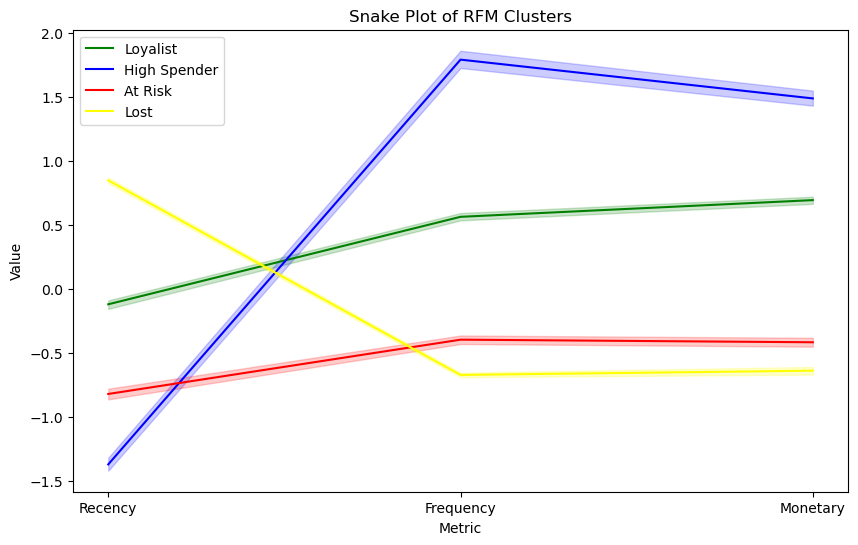

In [97]:
rmf_melt = pd.melt(rmf_df.reset_index(),
                   id_vars=['CustomerID','Segments'],
                   value_vars=['Recency','Frequency','Monetary'],
                   var_name='Metric',
                   value_name='Value'
                   )

colors = ['Green','Blue', 'Red', 'Yellow']
plt.figure(figsize=(10, 6))
sns.lineplot(data=rmf_melt, x='Metric', y='Value', hue='Segments', palette=colors)
plt.title('Snake Plot of RFM Clusters')
plt.legend()
plt.show()